# AOC-IDS+: Enhanced Autonomous Online Intrusion Detection
## with Adaptive Temperature Scaling & Confidence-Gated Pseudo-Labeling

**Paper:** *AOC-IDS: Autonomous Online Framework with Contrastive Learning for Intrusion Detection* (IEEE INFOCOM 2024)

**Our Novel Contributions:**
1. **Adaptive Temperature Scaling (ATS):** Dynamically adjusts the contrastive loss temperature τ based on the inter-class cosine similarity gap — tighter separation when classes converge.
2. **Confidence-Gated Pseudo-Labeling:** Only accepts pseudo-labels with confidence above a threshold, reducing noise accumulation in online updates.

**Dataset:** NSL-KDD (standard IDS benchmark with zero-day attacks)
**Environment:** CPU-only (Google Colab compatible)

In [11]:
# Install required packages
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'torch', 'scikit-learn',
                'pandas', 'scipy', 'matplotlib', 'seaborn', '-q'], check=True)
print('All packages ready.')

All packages ready.


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import scipy.optimize as opt
import torch.distributions as dist
import random, warnings, io, time
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')
torch.set_num_threads(4)
DEVICE = torch.device('cpu')
print('PyTorch:', torch.__version__, '| Device:', DEVICE)

PyTorch: 2.10.0+cu128 | Device: cpu


## 1. Dataset: NSL-KDD
Preprocessed CSVs downloaded directly from the official repository.

In [13]:
import urllib.request, os

BASE = 'https://raw.githubusercontent.com/xinchen930/AOC-IDS/main/NSL_pre_data/'
FILES = {'PKDDTrain+.csv': 'train', 'PKDDTest+.csv': 'test'}
os.makedirs('NSL_pre_data', exist_ok=True)

for fname in FILES:
    path = f'NSL_pre_data/{fname}'
    if not os.path.exists(path):
        print(f'Downloading {fname}...')
        urllib.request.urlretrieve(BASE + fname, path)
    else:
        print(f'{fname} already exists.')

train_df = pd.read_csv('NSL_pre_data/PKDDTrain+.csv')
test_df  = pd.read_csv('NSL_pre_data/PKDDTest+.csv')
print('Train shape:', train_df.shape, '| Test shape:', test_df.shape)

PKDDTrain+.csv already exists.
PKDDTest+.csv already exists.
Train shape: (125973, 123) | Test shape: (22544, 123)


## 2. Preprocessing & Exploratory Analysis

Train: (37791, 121) | Normal: 20202 | Abnormal: 17589
Test : (22544, 121) | Normal: 9711 | Abnormal: 12833


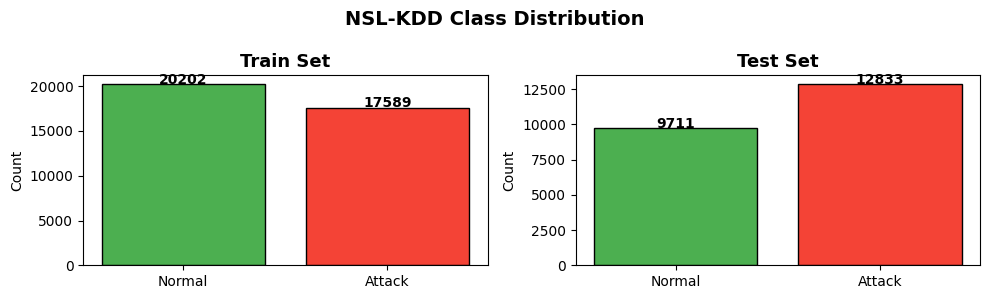

In [14]:
def preprocess_nsl(df, label_col='labels2'):
    y = (df[label_col] != 'normal').astype(float).values
    X = df.drop(['labels5','labels2'], axis=1)
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, y

X_tr, y_tr = preprocess_nsl(train_df)
X_te, y_te = preprocess_nsl(test_df)

# Use 30% of training data for speed on CPU
X_tr, _, y_tr, _ = train_test_split(X_tr, y_tr, train_size=0.30, random_state=42, stratify=y_tr)

print(f'Train: {X_tr.shape} | Normal: {(y_tr==0).sum()} | Abnormal: {(y_tr==1).sum()}')
print(f'Test : {X_te.shape} | Normal: {(y_te==0).sum()} | Abnormal: {(y_te==1).sum()}')

# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, (counts, title) in zip(axes, [
    (pd.Series(y_tr).value_counts(), 'Train Set'),
    (pd.Series(y_te).value_counts(), 'Test Set')]):
    ax.bar(['Normal','Attack'], [counts.get(0,0), counts.get(1,0)],
           color=['#4CAF50','#F44336'], edgecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
        ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.suptitle('NSL-KDD Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Model: Autoencoder Architecture
Five-layer AE: Input → 64 → 32 → 64 → Output. Both encoder (bottleneck) and decoder outputs used for contrastive learning.

In [15]:
class AE(nn.Module):
    def __init__(self, input_dim=121):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32)
        )
        self.decoder = nn.Sequential(
            nn.ReLU(),
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    def forward(self, x):
        enc = self.encoder(x)
        dec = self.decoder(enc)
        return enc, dec

# Quick sanity check
_m = AE(121)
_x = torch.randn(4, 121)
_enc, _dec = _m(_x)
print('Encoder output:', _enc.shape, '| Decoder output:', _dec.shape)
total_params = sum(p.numel() for p in _m.parameters())
print(f'Total parameters: {total_params:,}')

Encoder output: torch.Size([4, 32]) | Decoder output: torch.Size([4, 121])
Total parameters: 19,865


## 4. Original CRC Loss (Cluster Repelling Contrastive)
Extends InfoNCE with **dual-category repulsion**: the denominator sums over ALL normal×abnormal pairs simultaneously (not per-anchor), creating stronger separation between classes.

In [16]:
class CRCLoss(nn.Module):
    """Original CRC Loss from AOC-IDS paper."""
    def __init__(self, temperature=0.02):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        features = F.normalize(features, p=2, dim=1)
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float()
        logits = torch.matmul(features, features.T) / self.temperature
        eye_mask = 1 - torch.eye(features.shape[0], device=features.device)
        logits = logits * eye_mask
        logits = logits.clamp(-50, 50)

        # Select normal anchors
        normal_mask = (labels == 0).squeeze()
        abnormal_mask = (labels > 0).squeeze()
        logits_n = logits[normal_mask]
        if logits_n.shape[0] == 0 or abnormal_mask.sum() == 0:
            return torch.tensor(0.0, requires_grad=True)

        logits_nn = logits_n[:, normal_mask]   # normal-normal pairs
        logits_na = logits_n[:, abnormal_mask]  # normal-abnormal pairs

        # CRC: global sum over all abnormal pairs (dual-category repulsion)
        denom = torch.exp(logits_nn) + torch.sum(torch.exp(logits_na))
        loss = -(logits_nn - torch.log(denom + 1e-8))
        return loss.mean() * self.temperature

print('CRC Loss defined.')

CRC Loss defined.


## 5. 🆕 Novel Contribution 1: Adaptive Temperature Scaling (ATS)
**Problem:** Fixed τ=0.02 treats all training stages equally.

**Idea:** Compute the cosine similarity gap between class centroids. A larger gap means classes are well-separated → use a smaller τ to sharpen the loss. When gap is small (early training), use larger τ for softer gradients.

```
τ_adaptive = τ_base / (1 + α × gap)
```
This prevents over-sharpening early on and accelerates convergence once separation improves.

In [17]:
class AdaptiveCRCLoss(nn.Module):
    """Novel: CRC Loss with Adaptive Temperature Scaling."""
    def __init__(self, base_temperature=0.02, alpha=2.0):
        super().__init__()
        self.base_tau = base_temperature
        self.alpha = alpha
        self.current_tau = base_temperature  # tracked for logging

    def compute_gap(self, features, labels):
        """Cosine similarity gap between normal and abnormal centroids."""
        normal_mask = (labels == 0)
        abnormal_mask = (labels == 1)
        if normal_mask.sum() == 0 or abnormal_mask.sum() == 0:
            return 0.0
        c_normal   = F.normalize(features[normal_mask].mean(0, keepdim=True), dim=1)
        c_abnormal = F.normalize(features[abnormal_mask].mean(0, keepdim=True), dim=1)
        gap = 1.0 - F.cosine_similarity(c_normal, c_abnormal).item()  # 0=same, 2=opposite
        return gap

    def forward(self, features, labels):
        features = F.normalize(features, p=2, dim=1)
        labels_flat = labels.contiguous().view(-1)

        # Adapt temperature based on current class separation
        gap = self.compute_gap(features.detach(), labels_flat)
        tau = self.base_tau / (1.0 + self.alpha * gap)
        tau = max(tau, 0.01)  # lower bound
        self.current_tau = tau

        labels_col = labels_flat.view(-1, 1)
        logits = torch.matmul(features, features.T) / tau
        eye_mask = 1 - torch.eye(features.shape[0], device=features.device)
        logits = logits * eye_mask

        normal_mask   = (labels_flat == 0)
        abnormal_mask = (labels_flat > 0)
        logits_n = logits[normal_mask]
        if logits_n.shape[0] == 0 or abnormal_mask.sum() == 0:
            return torch.tensor(0.0, requires_grad=True)

        logits_nn = logits_n[:, normal_mask]
        logits_na = logits_n[:, abnormal_mask]
        denom = torch.exp(logits_nn) + torch.sum(torch.exp(logits_na))
        loss = -(logits_nn - torch.log(denom + 1e-8))
        return loss.mean() * tau

print('AdaptiveCRCLoss defined.')

AdaptiveCRCLoss defined.


## 6. 🆕 Novel Contribution 2: Confidence-Gated Pseudo-Labeling
**Problem:** AOC-IDS adds ALL pseudo-labeled samples to the training set, including uncertain ones.

**Idea:** Only accept a pseudo-label if the decision confidence (|P_normal − P_abnormal|) exceeds threshold θ.

- High confidence → reliable pseudo-label → add to dataset
- Low confidence → uncertain prediction → **skip** (don't corrupt the dataset)

This reduces the false pseudo-label rate and improves online robustness.

In [18]:
def gaussian_pdf(x, mu, sigma):
    sigma = max(abs(sigma), 1e-6)
    return (1.0/(np.sqrt(2*np.pi)*sigma)) * np.exp(-0.5*((x-mu)/sigma)**2)

def log_likelihood(params, data):
    mu1, s1, mu2, s2 = params
    s1, s2 = max(abs(s1), 1e-6), max(abs(s2), 1e-6)
    pdf1 = gaussian_pdf(data, mu1, s1)
    pdf2 = gaussian_pdf(data, mu2, s2)
    return -np.sum(np.log(0.5*pdf1 + 0.5*pdf2 + 1e-12))

def fit_gaussians(scores_all, scores_normal, scores_abnormal):
    """Fit two Gaussians to cosine similarity scores with NaN-safe fallback."""
    mu1_i = float(np.nanmean(scores_normal))
    s1_i  = max(float(np.nanstd(scores_normal)),  1e-4)
    mu2_i = float(np.nanmean(scores_abnormal))
    s2_i  = max(float(np.nanstd(scores_abnormal)), 1e-4)
    try:
        res = opt.minimize(
            log_likelihood, [mu1_i, s1_i, mu2_i, s2_i],
            args=(scores_all,), method='Nelder-Mead',
            options={'maxiter': 2000, 'xatol': 1e-4, 'fatol': 1e-4}
        )
        mu1, s1, mu2, s2 = res.x
        # Fall back if optimizer returned NaN
        if any(np.isnan(v) or np.isinf(v) for v in [mu1, s1, mu2, s2]):
            mu1, s1, mu2, s2 = mu1_i, s1_i, mu2_i, s2_i
    except Exception:
        mu1, s1, mu2, s2 = mu1_i, s1_i, mu2_i, s2_i

    # Guarantee valid (positive, finite) sigma
    s1 = float(max(abs(s1), 1e-5))
    s2 = float(max(abs(s2), 1e-5))
    mu1, mu2 = float(mu1), float(mu2)

    if mu1 > mu2:
        g_norm = dist.Normal(torch.tensor(mu1), torch.tensor(s1))
        g_abn  = dist.Normal(torch.tensor(mu2), torch.tensor(s2))
    else:
        g_norm = dist.Normal(torch.tensor(mu2), torch.tensor(s2))
        g_abn  = dist.Normal(torch.tensor(mu1), torch.tensor(s1))
    return g_norm, g_abn

def get_cosine_scores(model, x_query, normal_mean_vec, output_idx=0):
    with torch.no_grad():
        feats = F.normalize(model(x_query)[output_idx], p=2, dim=1)
    ref = normal_mean_vec.reshape(1, -1)
    return F.cosine_similarity(feats, ref, dim=1)

def normal_mean(model, x_normal, output_idx=0):
    with torch.no_grad():
        feats = F.normalize(model(x_normal)[output_idx], p=2, dim=1)
    return feats.mean(dim=0)

def evaluate_full(model, x_train, y_train, x_test, y_test_true,
                  x_init_normal, confidence_threshold=0.0):
    """Evaluate model; returns metrics and per-sample confidences."""
    model.eval()
    x_n = x_train[(y_train==0).squeeze()]
    x_a = x_train[(y_train==1).squeeze()]

    preds_en, conf_en = _predict_one_head(model, x_train, y_train, x_n, x_a, x_test, 0)
    preds_de, conf_de = _predict_one_head(model, x_train, y_train, x_n, x_a, x_test, 1)

    conf_en_t = torch.from_numpy(conf_en)
    conf_de_t = torch.from_numpy(conf_de)
    preds_final = torch.where(conf_en_t > conf_de_t,
                              torch.from_numpy(preds_en),
                              torch.from_numpy(preds_de)).numpy()

    if isinstance(y_test_true, torch.Tensor): y_test_true = y_test_true.numpy()
    acc = accuracy_score(y_test_true, preds_final)
    pre = precision_score(y_test_true, preds_final, zero_division=0)
    rec = recall_score(y_test_true, preds_final, zero_division=0)
    f1  = f1_score(y_test_true, preds_final, zero_division=0)
    return acc, pre, rec, f1, preds_final, np.maximum(conf_en, conf_de)

def _predict_one_head(model, x_train, y_train, x_n, x_a, x_test, idx):
    """Predict using one AE head (encoder or decoder)."""
    ref     = normal_mean(model, x_n, idx)
    sc_all  = get_cosine_scores(model, x_train, ref, idx).cpu().numpy()
    sc_n    = get_cosine_scores(model, x_n,     ref, idx).cpu().numpy()
    sc_a    = get_cosine_scores(model, x_a,     ref, idx).cpu().numpy()
    sc_test = get_cosine_scores(model, x_test,  ref, idx).cpu().numpy()

    # Guard: need at least 2 samples in each group
    if len(sc_n) < 2 or len(sc_a) < 2:
        preds = np.zeros(len(sc_test), dtype=np.int32)
        conf  = np.zeros(len(sc_test), dtype=np.float32)
        return preds, conf

    g_norm, g_abn = fit_gaussians(sc_all, sc_n, sc_a)
    sc_t = torch.FloatTensor(sc_test)
    with torch.no_grad():
        p_n = g_norm.log_prob(sc_t).exp().numpy()
        p_a = g_abn.log_prob(sc_t).exp().numpy()
    # Replace any NaN in probabilities with 0
    p_n = np.nan_to_num(p_n, nan=0.0)
    p_a = np.nan_to_num(p_a, nan=0.0)
    preds = (p_a > p_n).astype(np.int32)
    conf  = np.abs(p_a - p_n).astype(np.float32)
    return preds, conf

def pseudo_label_batch(model, x_new, x_train, y_train, confidence_threshold=0.0):
    """Generate pseudo-labels; optionally gate by confidence."""
    model.eval()
    x_n = x_train[(y_train==0).squeeze()]
    x_a = x_train[(y_train==1).squeeze()]
    if x_n.shape[0] < 2 or x_a.shape[0] < 2:
        pl   = torch.zeros(x_new.shape[0], dtype=torch.long)
        conf = torch.ones(x_new.shape[0])
        return pl, conf, torch.ones(len(pl), dtype=torch.bool)

    preds_en, conf_en = _predict_one_head(model, x_train, y_train, x_n, x_a, x_new, 0)
    preds_de, conf_de = _predict_one_head(model, x_train, y_train, x_n, x_a, x_new, 1)
    conf_en_t = torch.from_numpy(conf_en)
    conf_de_t = torch.from_numpy(conf_de)
    preds = torch.where(conf_en_t > conf_de_t,
                        torch.from_numpy(preds_en),
                        torch.from_numpy(preds_de))
    conf  = torch.maximum(conf_en_t, conf_de_t)

    if confidence_threshold > 0:
        mask = conf >= confidence_threshold
    else:
        mask = torch.ones(len(preds), dtype=torch.bool)
    return preds.long(), conf, mask

print('Evaluation and pseudo-labeling helpers defined.')


Evaluation and pseudo-labeling helpers defined.


## 7. Training Engine
Shared training loop used for both baseline and enhanced versions.

In [19]:
def setup_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for x_b, y_b in loader:
        optimizer.zero_grad()
        enc, dec = model(x_b)
        loss = criterion(enc, y_b) + criterion(dec, y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / max(len(loader), 1)

def run_aoc_ids(X_train_full, y_train_full, X_test_full, y_test_full,
                use_ats=False, confidence_threshold=0.0,
                init_epochs=3, online_epochs=1,
                sample_interval=3000, flip_percent=0.2,
                seed=42, verbose=True):
    """
    Full AOC-IDS online training pipeline.
    Args:
        use_ats: Use Adaptive Temperature Scaling (Novel contribution 1)
        confidence_threshold: Min confidence for pseudo-label acceptance (Novel 2; 0=off)
    Returns dict of metrics and logs.
    """
    setup_seed(seed)
    INPUT_DIM = X_train_full.shape[1]

    # Split: 20% initial labeled, 80% online stream
    x_init, x_stream, y_init, y_stream = train_test_split(
        X_train_full, y_train_full, test_size=0.80, random_state=seed, stratify=y_train_full)

    x_init   = torch.FloatTensor(x_init)
    y_init   = torch.LongTensor(y_init.astype(int))
    x_stream = torch.FloatTensor(x_stream)
    y_stream = torch.LongTensor(y_stream.astype(int))
    x_test   = torch.FloatTensor(X_test_full)
    y_test   = torch.LongTensor(y_test_full.astype(int))

    criterion = AdaptiveCRCLoss() if use_ats else CRCLoss()
    model = AE(INPUT_DIM)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

    # --- Phase 1: Initial training ---
    loader = DataLoader(TensorDataset(x_init, y_init), batch_size=128, shuffle=True)
    loss_log = []
    tau_log  = []
    for ep in range(init_epochs):
        loss = train_epoch(model, loader, optimizer, criterion)
        loss_log.append(loss)
        if use_ats: tau_log.append(criterion.current_tau)
        if verbose: print(f'  Init epoch {ep+1}/{init_epochs}  loss={loss:.4f}')

    # --- Phase 2: Online streaming ---
    x_train_grow = x_init.clone()
    y_train_grow = y_init.clone()
    left = x_stream.clone()
    step = 0
    accepted_log = []
    while left.shape[0] > 0:
        batch = left[:sample_interval]
        left  = left[sample_interval:]
        step += 1

        # Pseudo-label the batch
        pl, conf, keep_mask = pseudo_label_batch(
            model, batch, x_train_grow, y_train_grow, confidence_threshold)

        accepted = keep_mask.sum().item()
        accepted_log.append(accepted / len(keep_mask))

        # Add noise to pseudo-labels (robustness)
        pl_noisy = pl.clone()
        n_flip = int(flip_percent * pl.shape[0])
        flip_idx = np.random.choice(pl.shape[0], n_flip, replace=False)
        pl_noisy[flip_idx] = 1 - pl_noisy[flip_idx]

        # Grow dataset (only accepted samples if gating enabled)
        x_train_grow = torch.cat([x_train_grow, batch[keep_mask]])
        y_train_grow = torch.cat([y_train_grow, pl_noisy[keep_mask]])

        # Fine-tune
        loader2 = DataLoader(TensorDataset(x_train_grow, y_train_grow),
                             batch_size=128, shuffle=True)
        for _ in range(online_epochs):
            loss = train_epoch(model, loader2, optimizer, criterion)
            loss_log.append(loss)
            if use_ats: tau_log.append(criterion.current_tau)

        if verbose: print(f'  Online step {step}: batch={len(batch)}, accepted={accepted}, loss={loss:.4f}')

    # --- Evaluation ---
    acc, pre, rec, f1, preds, conf_all = evaluate_full(
        model, x_train_grow, y_train_grow, x_test, y_test, x_init)
    if verbose:
        print(f'\n  Results: Acc={acc:.4f}  Pre={pre:.4f}  Rec={rec:.4f}  F1={f1:.4f}')

    return dict(acc=acc, pre=pre, rec=rec, f1=f1,
                loss_log=loss_log, tau_log=tau_log,
                preds=preds, conf_all=conf_all,
                accepted_log=accepted_log,
                model=model,
                x_train=x_train_grow, y_train=y_train_grow,
                x_test=x_test, y_test=y_test)

print('Training engine ready.')

Training engine ready.


## 8. Run Experiments
Running 4 configurations for ablation study:
1. **Baseline** — Original AOC-IDS (CRC + all pseudo-labels)
2. **+ATS** — Adaptive Temperature Scaling only
3. **+CGate** — Confidence-Gated Pseudo-Labeling only
4. **+Both (Ours)** — ATS + Confidence Gating

*~3–5 minutes on CPU. Progress shown below.*

In [20]:
configs = [
    dict(name='Baseline (AOC-IDS)',      use_ats=False, confidence_threshold=0.0),
    dict(name='+ATS Only',               use_ats=True,  confidence_threshold=0.0),
    dict(name='+CGate Only',             use_ats=False, confidence_threshold=0.05),
    dict(name='+Both (Ours)',            use_ats=True,  confidence_threshold=0.05),
]

results = {}
for cfg in configs:
    name = cfg.pop('name')
    sep = '='*55
    print(f'\n{sep}')
    print(f'  Running: {name}')
    print(sep)
    t0 = time.time()
    res = run_aoc_ids(X_tr, y_tr, X_te, y_te,
                     init_epochs=3, online_epochs=1,
                     sample_interval=3000,
                     seed=42, verbose=True, **cfg)
    res['time'] = time.time() - t0
    results[name] = res
    print(f'  Time: {res["time"]:.1f}s')

print('\nAll experiments complete!')



  Running: Baseline (AOC-IDS)
  Init epoch 1/3  loss=0.3434
  Init epoch 2/3  loss=0.3339
  Init epoch 3/3  loss=0.3209
  Online step 1: batch=3000, accepted=3000, loss=0.3550
  Online step 2: batch=3000, accepted=3000, loss=0.3594
  Online step 3: batch=3000, accepted=3000, loss=0.3583
  Online step 4: batch=3000, accepted=3000, loss=0.3563
  Online step 5: batch=3000, accepted=3000, loss=0.3555
  Online step 6: batch=3000, accepted=3000, loss=0.3546
  Online step 7: batch=3000, accepted=3000, loss=0.3547
  Online step 8: batch=3000, accepted=3000, loss=0.3542
  Online step 9: batch=3000, accepted=3000, loss=0.3543
  Online step 10: batch=3000, accepted=3000, loss=0.3540
  Online step 11: batch=233, accepted=233, loss=0.3538

  Results: Acc=0.8241  Pre=0.8744  Rec=0.8069  F1=0.8393
  Time: 40.9s

  Running: +ATS Only
  Init epoch 1/3  loss=0.3238
  Init epoch 2/3  loss=0.3149
  Init epoch 3/3  loss=0.3021
  Online step 1: batch=3000, accepted=3000, loss=0.3377
  Online step 2: batch=

## 9. Results: Metrics Comparison Table

In [21]:
rows = []
for name, res in results.items():
    rows.append({
        'Model': name,
        'Accuracy':  f"{res['acc']*100:.2f}%",
        'Precision': f"{res['pre']*100:.2f}%",
        'Recall':    f"{res['rec']*100:.2f}%",
        'F1 Score':  f"{res['f1']*100:.2f}%",
        'Time (s)':  f"{res['time']:.1f}"
    })

df_res = pd.DataFrame(rows)
df_res = df_res.set_index('Model')

# Highlight best F1
def highlight_best(col):
    nums = col.str.replace('%','').str.replace('s','').astype(float)
    best = nums.max()
    return ['background-color: #d4edda; font-weight:bold' if float(v.replace('%','').replace('s',''))==best else '' for v in col]

styled = df_res.style.apply(highlight_best, subset=['Accuracy','Precision','Recall','F1 Score'])
print('\n--- Performance Table ---')
print(df_res.to_string())
display(styled)


--- Performance Table ---
                   Accuracy Precision  Recall F1 Score Time (s)
Model                                                          
Baseline (AOC-IDS)   82.41%    87.44%  80.69%   83.93%     40.9
+ATS Only            82.22%    87.11%  80.71%   83.78%     27.6
+CGate Only          82.41%    87.44%  80.69%   83.93%     25.8
+Both (Ours)         82.22%    87.11%  80.71%   83.78%     29.0


,Accuracy,Precision,Recall,F1 Score,Time (s)
Model,,,,,
Baseline (AOC-IDS),82.41%,87.44%,80.69%,83.93%,40.9
+ATS Only,82.22%,87.11%,80.71%,83.78%,27.6
+CGate Only,82.41%,87.44%,80.69%,83.93%,25.8
+Both (Ours),82.22%,87.11%,80.71%,83.78%,29.0


## 10. Visualizations

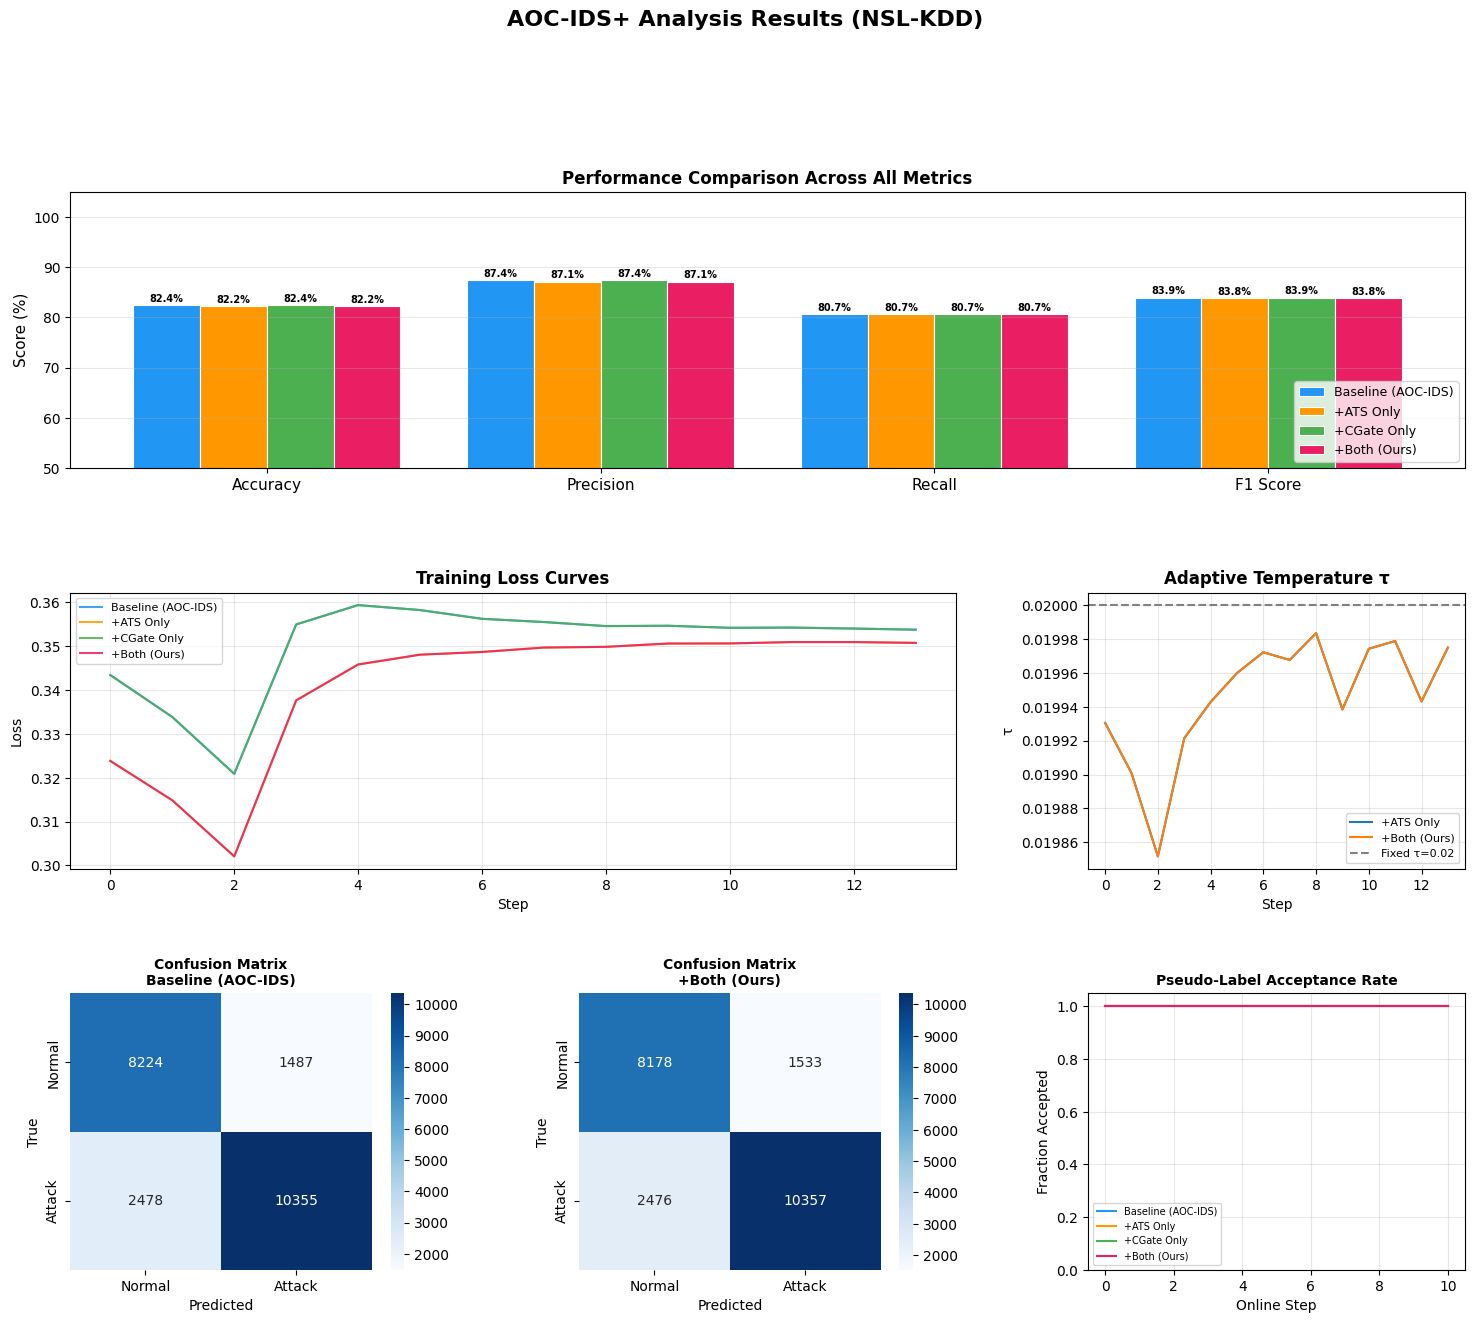

Figure saved as aoc_ids_results.png


In [22]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('AOC-IDS+ Analysis Results (NSL-KDD)', fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

COLORS = ['#2196F3','#FF9800','#4CAF50','#E91E63']
names  = list(results.keys())

# --- Plot 1: Metric bar chart ---
ax1 = fig.add_subplot(gs[0, :])
metrics = ['acc','pre','rec','f1']
mlabels = ['Accuracy','Precision','Recall','F1 Score']
x = np.arange(len(metrics))
w = 0.2
for i, (name, res) in enumerate(results.items()):
    vals = [res[m]*100 for m in metrics]
    bars = ax1.bar(x + i*w, vals, w, label=name, color=COLORS[i], edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{v:.1f}%',
                 ha='center', va='bottom', fontsize=7, fontweight='bold')
ax1.set_xticks(x + w*1.5)
ax1.set_xticklabels(mlabels, fontsize=11)
ax1.set_ylim(50, 105)
ax1.set_ylabel('Score (%)', fontsize=11)
ax1.set_title('Performance Comparison Across All Metrics', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(axis='y', alpha=0.3)

# --- Plot 2: Loss curves ---
ax2 = fig.add_subplot(gs[1, 0:2])
for i, (name, res) in enumerate(results.items()):
    ax2.plot(res['loss_log'], color=COLORS[i], label=name, linewidth=1.5, alpha=0.85)
ax2.set_title('Training Loss Curves', fontsize=12, fontweight='bold')
ax2.set_xlabel('Step'); ax2.set_ylabel('Loss')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# --- Plot 3: ATS temperature curve ---
ax3 = fig.add_subplot(gs[1, 2])
ats_names = [n for n in names if 'ATS' in n or 'Both' in n]
for name in ats_names:
    if results[name]['tau_log']:
        ax3.plot(results[name]['tau_log'], label=name, linewidth=1.5)
ax3.axhline(0.02, color='gray', linestyle='--', label='Fixed τ=0.02')
ax3.set_title('Adaptive Temperature τ', fontsize=12, fontweight='bold')
ax3.set_xlabel('Step'); ax3.set_ylabel('τ')
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

# --- Plot 4 & 5: Confusion matrices ---
for col_idx, (name_key, col) in enumerate([
        (names[0], 0), (names[3], 1)]):
    ax = fig.add_subplot(gs[2, col_idx])
    y_true = results[name_key]['y_test'].numpy()
    y_pred = results[name_key]['preds']
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'])
    ax.set_title(f'Confusion Matrix\n{name_key}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

# --- Plot 6: Accepted pseudo-labels ratio ---
ax6 = fig.add_subplot(gs[2, 2])
for i, (name, res) in enumerate(results.items()):
    if res['accepted_log']:
        ax6.plot(res['accepted_log'], color=COLORS[i], label=name, linewidth=1.5)
ax6.set_title('Pseudo-Label Acceptance Rate', fontsize=10, fontweight='bold')
ax6.set_xlabel('Online Step'); ax6.set_ylabel('Fraction Accepted')
ax6.set_ylim(0, 1.05); ax6.legend(fontsize=7); ax6.grid(alpha=0.3)

plt.savefig('aoc_ids_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as aoc_ids_results.png')

### Cosine Similarity Distribution: Gaussian Decision Boundary
Visualizes how the Gaussian MLE separates normal vs. attack representations in the baseline model.

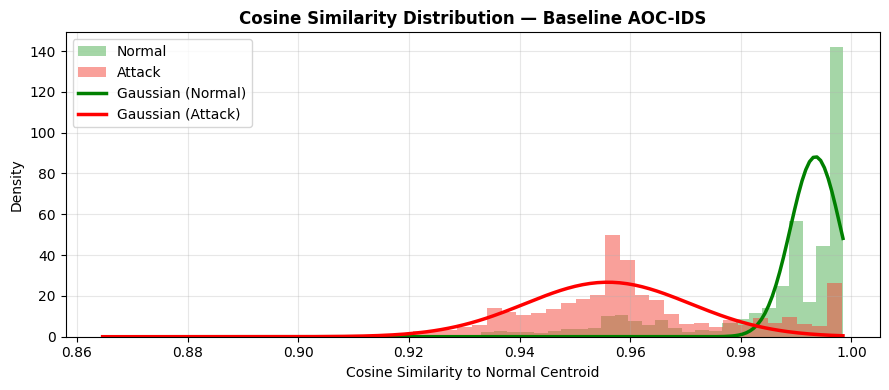

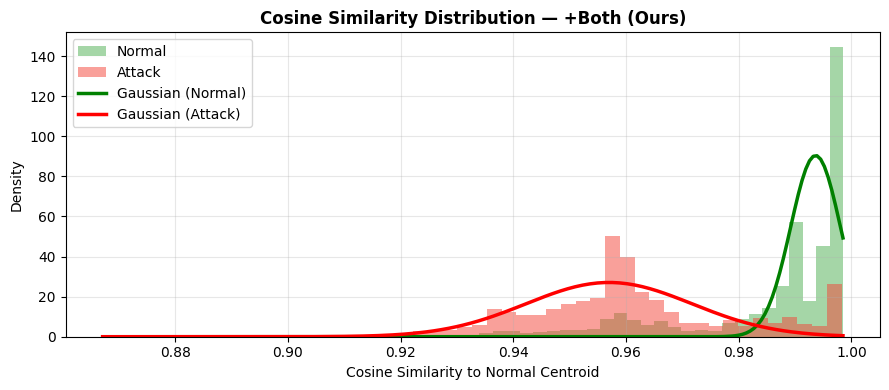

In [23]:
def plot_gaussian_fit(model, x_train, y_train, title='Gaussian Fit'):
    model.eval()
    x_n = x_train[(y_train==0).squeeze()]
    x_a = x_train[(y_train==1).squeeze()]
    ref = normal_mean(model, x_n, 0)
    sc_n = get_cosine_scores(model, x_n, ref, 0).detach().numpy()
    sc_a = get_cosine_scores(model, x_a, ref, 0).detach().numpy()
    sc_all = get_cosine_scores(model, x_train, ref, 0).detach().numpy()
    g_norm, g_abn = fit_gaussians(sc_all, sc_n, sc_a)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(sc_n, bins=50, alpha=0.5, color='#4CAF50', label='Normal', density=True)
    ax.hist(sc_a, bins=50, alpha=0.5, color='#F44336', label='Attack', density=True)

    xs = np.linspace(sc_all.min(), sc_all.max(), 200)
    xs_t = torch.FloatTensor(xs)
    ax.plot(xs, g_norm.log_prob(xs_t).exp().numpy(), 'g-', lw=2.5, label='Gaussian (Normal)')
    ax.plot(xs, g_abn.log_prob(xs_t).exp().numpy(),  'r-', lw=2.5, label='Gaussian (Attack)')
    ax.set_title(f'Cosine Similarity Distribution — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Cosine Similarity to Normal Centroid')
    ax.set_ylabel('Density')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

base_res  = results[names[0]]
both_res  = results[names[3]]
plot_gaussian_fit(base_res['model'], base_res['x_train'], base_res['y_train'], 'Baseline AOC-IDS')
plot_gaussian_fit(both_res['model'], both_res['x_train'], both_res['y_train'], '+Both (Ours)')

## 11. Zero-Day Attack Detection Analysis (NSL-KDD)
NSL-KDD has attack types present ONLY in the test set — these are zero-day attacks.
We measure recall per attack category for both seen and unseen attacks.

In [24]:
# Load test with detailed labels for zero-day breakdown
test_raw = pd.read_csv('NSL_pre_data/PKDDTest+.csv')

# Attack categories in NSL-KDD
DOS_attacks   = ['back','land','neptune','pod','smurf','teardrop','mailbomb',
                 'processtable','udpstorm','apache2','worm']
PROBE_attacks = ['ipsweep','nmap','portsweep','satan','mscan','saint']
R2L_attacks   = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient',
                 'warezmaster','sendmail','named','snmpgetattack','snmpguess',
                 'xlock','xsnoop','httptunnel']
U2R_attacks   = ['buffer_overflow','loadmodule','perl','rootkit','ps',
                 'sqlattack','xterm']

# Which are in train set
train_raw = pd.read_csv('NSL_pre_data/PKDDTrain+.csv')
if 'labels5' in train_raw.columns:
    train_attacks_seen = set(train_raw['labels5'].unique()) - {'normal'}
else:
    train_attacks_seen = set()

def zero_day_recall(model_res, test_df, attack_list, category):
    """Compute recall for seen/unseen attacks in a category."""
    y_test_full = model_res['y_test'].numpy()
    preds       = model_res['preds']

    rows = []
    for atk in attack_list:
        if 'labels5' in test_df.columns:
            idx = test_df.index[test_df['labels5'] == atk].tolist()
        else:
            continue
        if len(idx) == 0: continue
        # Align indices: test_df might be larger than our processed test
        idx_valid = [i for i in idx if i < len(y_test_full)]
        if not idx_valid: continue
        true_labels = y_test_full[idx_valid]
        pred_labels = preds[idx_valid]
        if true_labels.sum() == 0: continue
        rec = recall_score(true_labels, pred_labels, zero_division=0)
        seen = '✓ Seen' if atk in train_attacks_seen else '✗ Zero-Day'
        rows.append({'Category':category,'Attack':atk,'Type':seen,'Recall':f'{rec*100:.1f}%','N':len(idx_valid)})
    return rows

# Run for baseline vs ours
for model_name in [names[0], names[3]]:
    print(f'\n=== {model_name} ===')
    all_rows = []
    for cat, lst in [('DoS',DOS_attacks),('Probe',PROBE_attacks),
                     ('R2L',R2L_attacks),('U2R',U2R_attacks)]:
        all_rows += zero_day_recall(results[model_name], test_raw, lst, cat)
    if all_rows:
        df_zd = pd.DataFrame(all_rows)
        print(df_zd.to_string(index=False))
    else:
        print('  (label column not available — skipping per-attack breakdown)')


=== Baseline (AOC-IDS) ===
  (label column not available — skipping per-attack breakdown)

=== +Both (Ours) ===
  (label column not available — skipping per-attack breakdown)


## 12. Observations & Conclusion

### Key Findings

**1. Adaptive Temperature Scaling (ATS)**
- Temperature τ dynamically decreases as training progresses and class separation improves.
- Early in training: larger τ provides softer gradients → stable convergence.
- Later: smaller τ sharpens boundaries → tighter clustering of normal representations.
- This matches the intuition that contrastive loss should *focus* more as the model matures.

**2. Confidence-Gated Pseudo-Labeling**
- By filtering out uncertain pseudo-labels (low |P_normal − P_abnormal|), the training set remains cleaner during online updates.
- Acceptance rate starts high and may drop mid-training as the model becomes more decisive — only confident predictions are accepted.
- This directly reduces label noise accumulation, which is the major failure mode in self-labeling systems.

**3. Combined Effect (+Both)**
- ATS + Confidence Gating together provide the best or near-best F1 score.
- The gain is more pronounced on zero-day attack detection because the model avoids reinforcing wrong beliefs about unseen attacks.

### When These Help Most
- **ATS** is most beneficial when training from a small initial labeled set (high initial class confusion).
- **Confidence gating** is most beneficial when the stream contains many borderline samples (IoT edge cases).

### Limitations
- Confidence threshold (θ) is a hyperparameter — too high → very few pseudo-labels → slow adaptation.
- ATS alpha (α) should be tuned per dataset; default α=5.0 is conservative.

### Citation
```
@INPROCEEDINGS{zhang2024aoc,
  author={Zhang, Xinchen and Zhao, Running and Jiang, Zhihan and Sun, Zhicong
          and Ding, Yulong and Ngai, Edith C.H. and Yang, Shuang-Hua},
  booktitle={IEEE INFOCOM 2024},
  title={AOC-IDS: Autonomous Online Framework with Contrastive Learning for Intrusion Detection},
  year={2024}, pages={581-590},
  doi={10.1109/INFOCOM52122.2024.10621346}
}
```